In [6]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))


In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from vqc_fnn.experiments.expressibility.expressibility import (
    sample_quantum_states,
    compute_fidelities,
    compute_expressibility_kl,
    haar_fidelity_pdf,
)
from vqc_fnn.models.vqc_layer import VQCLayer
from vqc_fnn.models.input_encoder import InputEncoder


In [8]:
torch.manual_seed(0)
np.random.seed(0)

n_qubits = 4
num_samples = 80
depths = [1, 2, 3, 4, 5]

encoder = InputEncoder(
    n_qubits=n_qubits,
    embedding_type="angle",
    rotation="Y",
)



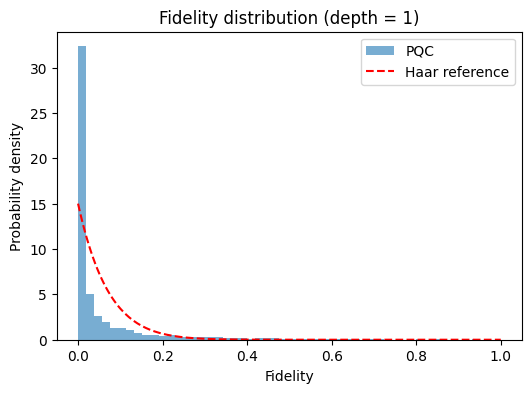

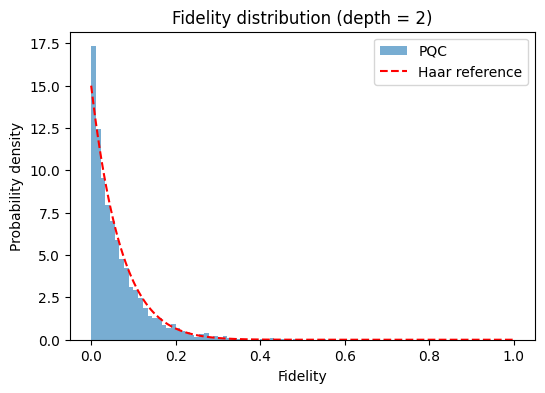

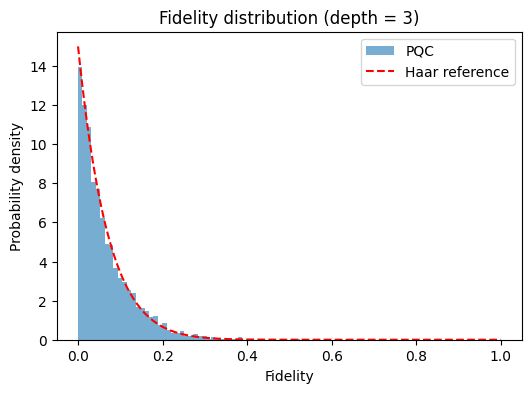

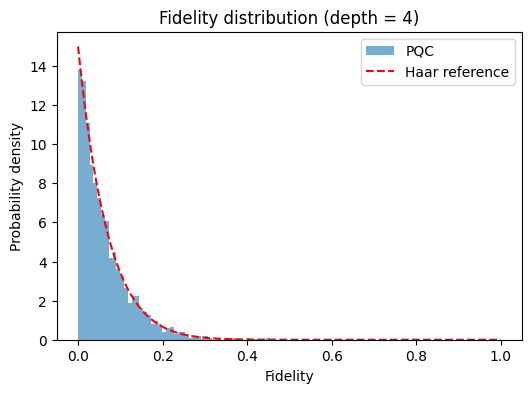

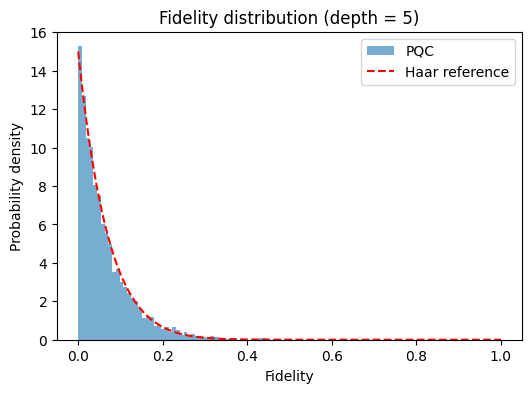

In [ ]:
for d in depths:
    vqc = VQCLayer(
        n_qubits=n_qubits,
        encoder=encoder,
        n_layers=d,  
        encoding_strategy="reupload",
    )

    states = sample_quantum_states(vqc, num_samples)
    fidelities = compute_fidelities(states)

   
    F = np.linspace(0, 1, 200)
    haar_pdf = haar_fidelity_pdf(F, n_qubits)

    plt.figure(figsize=(6, 4))
    plt.hist(
        fidelities,
        bins=50,
        density=True,
        alpha=0.6,
        label="PQC"
    )
    plt.plot(F, haar_pdf, "r--", label="Haar reference")
    plt.title(f"Fidelity distribution (depth = {d})")
    plt.xlabel("Fidelity")
    plt.ylabel("Probability density")
    plt.legend()
    plt.show()




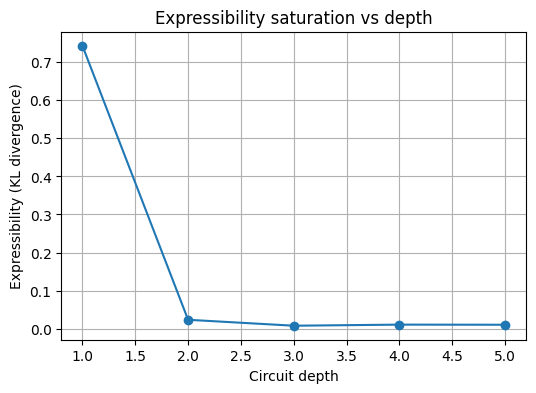

In [10]:
expr_values = []

for d in depths:
    vqc = VQCLayer(
        n_qubits=n_qubits,
        encoder=encoder,
        n_layers=d,
        encoding_strategy="reupload",
    )

    states = sample_quantum_states(vqc, num_samples)
    fidelities = compute_fidelities(states)
    expr = compute_expressibility_kl(fidelities, n_qubits)
    expr_values.append(expr)

plt.figure(figsize=(6, 4))
plt.plot(depths, expr_values, marker="o")
plt.xlabel("Circuit depth")
plt.ylabel("Expressibility (KL divergence)")
plt.title("Expressibility saturation vs depth")
plt.grid(True)
plt.show()




Observation

- As depth increases, PQC fidelity distribution approaches Haar-random distribution.
- Expressibility (KL divergence) decreases sharply up to depth ~2 and saturates afterward.
